# PRRSV Full Validation: Start Rescue Experiment

This notebook compares the previous PRRSV strict-clean validation against the experimental start-rescue logic on this branch.

Goal: check whether the new ref-length/frame-aware start rescue improves only `ORF7`, or also changes other PRRSV genes.

Flow:

1. Load previous PRRSV baseline output from `outputs_prrsv/`.
2. Rerun full PRRSV tblastn validation from scratch with the current code.
3. Recalculate per-gene evaluable accuracy using records where each ref gene exists in truth.
4. Compare baseline vs experiment per gene and inspect changed cases.

In [1]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import app.validation._shared.validation_utils as validation_utils
importlib.reload(validation_utils)
from app.validation._shared.validation_utils import *

TIER = 'strict_clean'
BASE_DIR = ROOT / 'app' / 'validation' / '04_tblastn_truth_breakdown_100seq' / 'tiers' / TIER
INPUT_DIR = BASE_DIR / 'inputs'
BASELINE_DIR = BASE_DIR / 'outputs_prrsv'
OUTPUT_DIR = BASE_DIR / 'prrsv_start_rescue_full_outputs'
DATA_DIR = ROOT / 'app' / 'data'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 140)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})

BASE_DIR, BASELINE_DIR, OUTPUT_DIR

(PosixPath('/Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean'),
 PosixPath('/Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean/outputs_prrsv'),
 PosixPath('/Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/04_tblastn_truth_breakdown_100seq/tiers/strict_clean/prrsv_start_rescue_full_outputs'))

## Load Baseline

Baseline is the previous PRRSV strict-clean run before this experimental rescue change. If the baseline files are missing, rerun `prrsv_tblastn_breakdown_strict_clean.ipynb` on the old/main logic first.

In [2]:
baseline_prediction_path = BASELINE_DIR / 'prrsv_tblastn_vs_truth.tsv'
baseline_accuracy_path = BASELINE_DIR / 'prrsv_per_gene_evaluable_accuracy.tsv'

if not baseline_prediction_path.exists():
    raise FileNotFoundError(f'Missing baseline predictions: {baseline_prediction_path}')

baseline_df = pd.read_csv(baseline_prediction_path, sep='	')
print('baseline predictions:', baseline_df.shape)

if baseline_accuracy_path.exists():
    baseline_per_gene = pd.read_csv(baseline_accuracy_path, sep='	')
else:
    baseline_per_gene = None
    print('Baseline per-gene accuracy file not found; it will be recomputed below.')

baseline_df.head()

baseline predictions: (855, 23)


,virus,record_id,method,ref_name,pred_name,source_name,pred_start,pred_end,strand,status,coverage,identity,score,truth_name,truth_start,truth_end,best_overlap_name,best_iou,iou,name_match,coord_correct,exact_match,failure_mode
0,PRRS,AF184212.1,tblastn,ORF1a,ORF1a,NaN,191,7810,+,ok,1.0000,90.1,4576.5,ORF1a,191.0,7810.0,ORF1a,1.0000,1.0000,True,True,True,Correct
1,PRRS,AF184212.1,tblastn,ORF1b,ORF1b,NaN,7795,12180,+,invalid_boundaries,1.0000,98.4,2997.2,ORF1b,7789.0,12180.0,ORF1b,0.9986,0.9986,True,True,False,Boundary offset
2,PRRS,AF184212.1,tblastn,ORF2a,ORF2a,NaN,12182,12952,+,ok,0.9961,93.7,495.4,ORF2a,12182.0,12952.0,ORF2a,1.0000,1.0000,True,True,True,Correct
3,PRRS,AF184212.1,tblastn,ORF2b,ORF2b,NaN,12187,12408,+,ok,1.0000,93.2,134.8,NaN,NaN,NaN,ORF2a,0.2879,0.0000,False,False,False,Possible overlap
4,PRRS,AF184212.1,tblastn,ORF3,ORF3,NaN,12805,13569,+,ok,1.0000,88.6,481.1,ORF3,12805.0,13569.0,ORF3,1.0000,1.0000,True,True,True,Correct


## Build Reference-Gene Truth Availability

This matches the PRRSV denominator logic: evaluate a ref gene only on records where query truth contains the same gene.

In [3]:
prrsv_bundle = load_reference_bundle(DATA_DIR / 'PRRS_ref_test.gb')
ref_model = pd.DataFrame(prrsv_bundle['features']).copy()
ref_model['ref_len'] = ref_model['end'] - ref_model['start'] + 1
ref_model = (
    ref_model.rename(columns={'name': 'ref_name', 'start': 'ref_start', 'end': 'ref_end'})
    [['ref_name', 'ref_start', 'ref_end', 'ref_len', 'strand']]
    .sort_values(['ref_start', 'ref_end'])
    .reset_index(drop=True)
)
ref_gene_names = ref_model['ref_name'].dropna().astype(str).tolist()

manifest = pd.read_csv(INPUT_DIR / 'manifest.tsv', sep='	')
prrsv_manifest = manifest[manifest['virus'].eq('PRRS')].copy()
validation_record_ids = set(prrsv_manifest[prrsv_manifest['keep'].eq(True)]['record_id'])
query_records = load_genbank_records(INPUT_DIR / 'PRRS_records.gb')

presence_rows = []
for record in query_records:
    if record.id not in validation_record_ids:
        continue
    validation_truth_features, _ = parse_validation_truth_features(
        record,
        prrsv_bundle['alias_lookup'],
        prrsv_bundle['feature_type'],
        prrsv_bundle['features'],
        'PRRS',
    )
    validation_names = {feature['name'] for feature in validation_truth_features}
    for gene in ref_gene_names:
        presence_rows.append({
            'record_id': record.id,
            'ref_name': gene,
            'validation_has_feature': gene in validation_names,
        })

truth_presence = pd.DataFrame(presence_rows)
truth_presence.to_csv(OUTPUT_DIR / 'prrsv_truth_presence_ref_genes.tsv', sep='	', index=False)
truth_presence.groupby('ref_name')['validation_has_feature'].sum().reset_index(name='truth_available_records')

,ref_name,truth_available_records
0,ORF1a,62
1,ORF1b,83
2,ORF2a,95
3,ORF2b,48
4,ORF3,95
5,ORF4,95
6,ORF5,95
7,ORF6,94
8,ORF7,94


## Helper: Per-Gene Evaluable Accuracy

In [4]:
def per_gene_evaluable_accuracy(df, truth_presence, ref_gene_names):
    rows = []
    case_rows = []
    for gene in ref_gene_names:
        gene_rows = df[df['ref_name'].eq(gene)].copy()
        truth_records = set(
            truth_presence[
                truth_presence['ref_name'].eq(gene) & truth_presence['validation_has_feature'].eq(True)
            ]['record_id']
        )
        evaluable = gene_rows[gene_rows['record_id'].isin(truth_records)].copy()
        extra = gene_rows[~gene_rows['record_id'].isin(truth_records)].copy()
        lifted = pd.to_numeric(evaluable['pred_start'], errors='coerce').notna()
        extra_lifted = pd.to_numeric(extra['pred_start'], errors='coerce').notna()

        exact_correct = int(evaluable['exact_match'].fillna(False).sum())
        coord_correct = int(evaluable['coord_correct'].fillna(False).sum())
        truth_available = len(evaluable)
        rows.append({
            'ref_name': gene,
            'truth_available_records': truth_available,
            'all_records': len(gene_rows),
            'lifted_with_truth': int(lifted.sum()),
            'not_lifted_with_truth': int(evaluable['status'].fillna('').eq('no_hit').sum()),
            'exact_correct': exact_correct,
            'coord_correct': coord_correct,
            'exact_wrong_or_nonexact': truth_available - exact_correct,
            'coord_wrong_or_missing': truth_available - coord_correct,
            'extra_predictions_without_truth': int(extra_lifted.sum()),
            'records_without_truth': len(extra),
            'exact_pct_on_truth': round(exact_correct / truth_available * 100, 2) if truth_available else None,
            'coord_pct_on_truth': round(coord_correct / truth_available * 100, 2) if truth_available else None,
        })
        for _, row in evaluable.iterrows():
            case_rows.append({
                'ref_name': gene,
                'record_id': row['record_id'],
                'pred_name': row.get('pred_name'),
                'truth_name': row.get('truth_name'),
                'status': row.get('status'),
                'failure_mode': row.get('failure_mode'),
                'exact_match': row.get('exact_match'),
                'coord_correct': row.get('coord_correct'),
                'pred_start': row.get('pred_start'),
                'pred_end': row.get('pred_end'),
                'truth_start': row.get('truth_start'),
                'truth_end': row.get('truth_end'),
                'iou': row.get('iou'),
                'best_overlap_name': row.get('best_overlap_name'),
                'best_iou': row.get('best_iou'),
            })
    return pd.DataFrame(rows), pd.DataFrame(case_rows)

baseline_per_gene_recomputed, baseline_cases = per_gene_evaluable_accuracy(baseline_df, truth_presence, ref_gene_names)
baseline_per_gene_recomputed.to_csv(OUTPUT_DIR / 'baseline_per_gene_evaluable_accuracy_recomputed.tsv', sep='	', index=False)
baseline_per_gene_recomputed

,ref_name,truth_available_records,all_records,lifted_with_truth,not_lifted_with_truth,exact_correct,coord_correct,exact_wrong_or_nonexact,coord_wrong_or_missing,extra_predictions_without_truth,records_without_truth,exact_pct_on_truth,coord_pct_on_truth
0,ORF1a,62,95,62,0,61,62,1,0,33,33,98.39,100.00
1,ORF1b,83,95,83,0,0,83,83,0,12,12,0.00,100.00
2,ORF2a,95,95,95,0,95,95,0,0,0,0,100.00,100.00
3,ORF2b,48,95,48,0,45,48,3,0,47,47,93.75,100.00
4,ORF3,95,95,95,0,95,95,0,0,0,0,100.00,100.00
5,ORF4,95,95,95,0,94,95,1,0,0,0,98.95,100.00
6,ORF5,95,95,95,0,91,95,4,0,0,0,95.79,100.00
7,ORF6,94,95,94,0,91,94,3,0,1,1,96.81,100.00
8,ORF7,94,95,94,0,66,66,28,28,1,1,70.21,70.21


## Rerun Full PRRSV tblastn With Experimental Rescue

This cell runs tblastn from scratch using the current branch code.

In [5]:
experiment_df, experiment_summary = run_tblastn_against_truth(
    virus_label='PRRS',
    ref_path=DATA_DIR / 'PRRS_ref_test.gb',
    query_path=INPUT_DIR / 'PRRS_records.gb',
    output_dir=OUTPUT_DIR / 'prrs',
    progress=True,
)

experiment_df.to_csv(OUTPUT_DIR / 'prrsv_tblastn_vs_truth_experimental.tsv', sep='	', index=False)
experiment_summary.to_csv(OUTPUT_DIR / 'prrsv_tblastn_summary_experimental.tsv', sep='	', index=False)
experiment_summary

tblastn  PRRS:   0%|          | 0/95 [00:00<?, ?rec/s]

,virus,method,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,PRRS,tblastn,855,674,758,0.8894,78.83,88.65


## Per-Gene Accuracy Comparison

In [6]:
experiment_per_gene, experiment_cases = per_gene_evaluable_accuracy(experiment_df, truth_presence, ref_gene_names)
experiment_per_gene.to_csv(OUTPUT_DIR / 'experiment_per_gene_evaluable_accuracy.tsv', sep='	', index=False)
experiment_cases.to_csv(OUTPUT_DIR / 'experiment_per_gene_cases.tsv', sep='	', index=False)

baseline_pg = baseline_per_gene_recomputed.add_prefix('baseline_').rename(columns={'baseline_ref_name': 'ref_name'})
experiment_pg = experiment_per_gene.add_prefix('experiment_').rename(columns={'experiment_ref_name': 'ref_name'})
comparison = baseline_pg.merge(experiment_pg, on='ref_name', how='outer')
for metric in ['exact_correct', 'coord_correct', 'exact_wrong_or_nonexact', 'coord_wrong_or_missing']:
    comparison[f'{metric}_delta'] = comparison[f'experiment_{metric}'] - comparison[f'baseline_{metric}']
for metric in ['exact_pct_on_truth', 'coord_pct_on_truth']:
    comparison[f'{metric}_delta'] = (comparison[f'experiment_{metric}'] - comparison[f'baseline_{metric}']).round(2)
comparison = comparison.sort_values(['exact_correct_delta', 'coord_correct_delta', 'ref_name'], ascending=[False, False, True])
comparison.to_csv(OUTPUT_DIR / 'prrsv_start_rescue_per_gene_comparison.tsv', sep='	', index=False)
comparison[[
    'ref_name',
    'baseline_truth_available_records',
    'baseline_exact_correct', 'experiment_exact_correct', 'exact_correct_delta',
    'baseline_coord_correct', 'experiment_coord_correct', 'coord_correct_delta',
    'baseline_exact_pct_on_truth', 'experiment_exact_pct_on_truth', 'exact_pct_on_truth_delta',
    'baseline_coord_pct_on_truth', 'experiment_coord_pct_on_truth', 'coord_pct_on_truth_delta',
]]

,ref_name,baseline_truth_available_records,baseline_exact_correct,experiment_exact_correct,exact_correct_delta,baseline_coord_correct,experiment_coord_correct,coord_correct_delta,baseline_exact_pct_on_truth,experiment_exact_pct_on_truth,exact_pct_on_truth_delta,baseline_coord_pct_on_truth,experiment_coord_pct_on_truth,coord_pct_on_truth_delta
8,ORF7,94,66,91,25,66,91,25,70.21,96.81,26.60,70.21,96.81,26.6
6,ORF5,95,91,95,4,95,95,0,95.79,100.00,4.21,100.00,100.00,0.0
3,ORF2b,48,45,48,3,48,48,0,93.75,100.00,6.25,100.00,100.00,0.0
7,ORF6,94,91,94,3,94,94,0,96.81,100.00,3.19,100.00,100.00,0.0
5,ORF4,95,94,95,1,95,95,0,98.95,100.00,1.05,100.00,100.00,0.0
0,ORF1a,62,61,61,0,62,62,0,98.39,98.39,0.00,100.00,100.00,0.0
1,ORF1b,83,0,0,0,83,83,0,0.00,0.00,0.00,100.00,100.00,0.0
2,ORF2a,95,95,95,0,95,95,0,100.00,100.00,0.00,100.00,100.00,0.0
4,ORF3,95,95,95,0,95,95,0,100.00,100.00,0.00,100.00,100.00,0.0


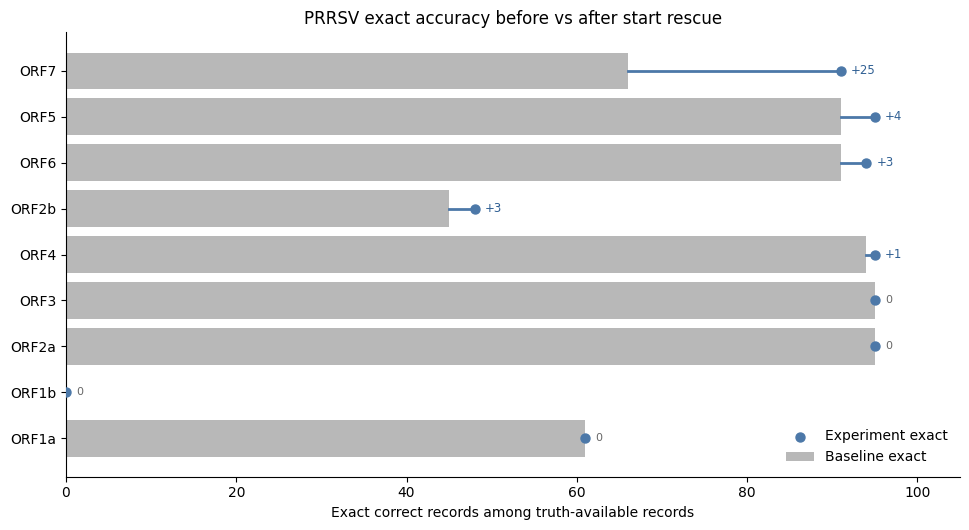

In [7]:
plot_df = comparison.sort_values(['exact_correct_delta', 'experiment_truth_available_records', 'ref_name'], ascending=[True, True, True]).copy()
fig, ax = plt.subplots(figsize=(9.8, 5.4))
y = range(len(plot_df))
ax.barh(y, plot_df['baseline_exact_correct'], label='Baseline exact', color='#B8B8B8')
ax.scatter(plot_df['experiment_exact_correct'], y, label='Experiment exact', color='#4C78A8', s=42, zorder=3)
for yi, row in zip(y, plot_df.to_dict('records')):
    if row['exact_correct_delta'] != 0:
        ax.plot([row['baseline_exact_correct'], row['experiment_exact_correct']], [yi, yi], color='#4C78A8', linewidth=2)
        ax.text(row['experiment_exact_correct'] + 1.2, yi, f"+{int(row['exact_correct_delta'])}", va='center', ha='left', fontsize=8.5, color='#2F5F93')
    else:
        ax.text(row['experiment_exact_correct'] + 1.2, yi, '0', va='center', ha='left', fontsize=8, color='#666666')
ax.set_yticks(list(y), plot_df['ref_name'])
ax.set_xlabel('Exact correct records among truth-available records')
ax.set_title('PRRSV exact accuracy before vs after start rescue')
ax.set_xlim(0, max(plot_df['experiment_truth_available_records'].max(), plot_df['baseline_truth_available_records'].max()) + 10)
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prrsv_start_rescue_exact_comparison.png', bbox_inches='tight')
plt.show()

## Changed Cases

Rows below changed coordinates, status, failure mode, or exact/coord correctness between baseline and experiment.

In [8]:
case_cols = [
    'record_id', 'ref_name', 'pred_name', 'pred_start', 'pred_end', 'truth_name', 'truth_start', 'truth_end',
    'status', 'failure_mode', 'exact_match', 'coord_correct', 'iou', 'coverage', 'identity'
]
base_cases = baseline_df[[c for c in case_cols if c in baseline_df.columns]].copy().add_prefix('baseline_')
exp_cases = experiment_df[[c for c in case_cols if c in experiment_df.columns]].copy().add_prefix('experiment_')
changed = base_cases.merge(
    exp_cases,
    left_on=['baseline_record_id', 'baseline_ref_name'],
    right_on=['experiment_record_id', 'experiment_ref_name'],
    how='outer',
)
changed['coords_changed'] = (
    changed['baseline_pred_start'].astype('Int64') != changed['experiment_pred_start'].astype('Int64')
) | (
    changed['baseline_pred_end'].astype('Int64') != changed['experiment_pred_end'].astype('Int64')
)
changed['status_changed'] = changed['baseline_status'].astype(str) != changed['experiment_status'].astype(str)
changed['failure_changed'] = changed['baseline_failure_mode'].astype(str) != changed['experiment_failure_mode'].astype(str)
changed['exact_changed'] = changed['baseline_exact_match'].astype(str) != changed['experiment_exact_match'].astype(str)
changed['coord_changed'] = changed['baseline_coord_correct'].astype(str) != changed['experiment_coord_correct'].astype(str)
changed = changed[changed[['coords_changed', 'status_changed', 'failure_changed', 'exact_changed', 'coord_changed']].any(axis=1)].copy()
changed.to_csv(OUTPUT_DIR / 'prrsv_start_rescue_changed_cases.tsv', sep='	', index=False)
changed[[
    'baseline_record_id', 'baseline_ref_name',
    'baseline_pred_start', 'baseline_pred_end', 'experiment_pred_start', 'experiment_pred_end',
    'baseline_truth_start', 'baseline_truth_end',
    'baseline_status', 'experiment_status',
    'baseline_failure_mode', 'experiment_failure_mode',
    'baseline_exact_match', 'experiment_exact_match',
    'baseline_coord_correct', 'experiment_coord_correct',
    'baseline_iou', 'experiment_iou',
]].sort_values(['baseline_ref_name', 'baseline_record_id']).head(120)

,baseline_record_id,baseline_ref_name,baseline_pred_start,baseline_pred_end,experiment_pred_start,experiment_pred_end,baseline_truth_start,baseline_truth_end,baseline_status,experiment_status,baseline_failure_mode,experiment_failure_mode,baseline_exact_match,experiment_exact_match,baseline_coord_correct,experiment_coord_correct,baseline_iou,experiment_iou
586,EF536002.1,ORF1b,7507,11906,7507,11906,NaN,NaN,ok_rescued,invalid_boundaries,Possible overlap,Possible overlap,False,False,False,False,0.0000,0.0
147,AY366525.1,ORF2b,11745,11962,11750,11962,11750.0,11962.0,ok_rescued,ok_rescued,Boundary offset,Correct,False,True,True,True,0.9771,1.0
264,DQ489311.1,ORF2b,11745,11962,11750,11962,11750.0,11962.0,ok_rescued,ok_rescued,Boundary offset,Correct,False,True,True,True,0.9771,1.0
282,DQ864705.1,ORF2b,11719,11936,11724,11936,NaN,NaN,ok_rescued,ok_rescued,Possible overlap,Possible overlap,False,False,False,False,0.0000,0.0
624,EU076704.1,ORF2b,11796,12013,11801,12013,11801.0,12013.0,ok_rescued,ok_rescued,Boundary offset,Correct,False,True,True,True,0.9771,1.0
284,DQ864705.1,ORF4,12914,13420,12869,13420,12869.0,13420.0,ok_rescued,ok_rescued,Boundary offset,Correct,False,True,True,True,0.9185,1.0
150,AY366525.1,ORF5,13448,14048,13443,14048,13443.0,14048.0,ok_rescued,ok_rescued,Boundary offset,Correct,False,True,True,True,0.9917,1.0
267,DQ489311.1,ORF5,13448,14048,13443,14048,13443.0,14048.0,ok_rescued,ok_rescued,Boundary offset,Correct,False,True,True,True,0.9917,1.0
285,DQ864705.1,ORF5,13422,14022,13417,14022,13417.0,14022.0,ok_rescued,ok_rescued,Boundary offset,Correct,False,True,True,True,0.9917,1.0
627,EU076704.1,ORF5,13475,14075,13470,14075,13470.0,14075.0,ok_rescued,ok_rescued,Boundary offset,Correct,False,True,True,True,0.9917,1.0


## Changed Case Summary By Gene

In [9]:
if changed.empty:
    print('No changed cases.')
else:
    changed_summary = (
        changed.groupby('baseline_ref_name', dropna=False)
        .agg(
            changed_cases=('baseline_record_id', 'size'),
            exact_improved=('experiment_exact_match', lambda s: int(s.fillna(False).sum())),
            baseline_exact=('baseline_exact_match', lambda s: int(s.fillna(False).sum())),
            coord_improved=('experiment_coord_correct', lambda s: int(s.fillna(False).sum())),
            baseline_coord=('baseline_coord_correct', lambda s: int(s.fillna(False).sum())),
        )
        .reset_index()
        .rename(columns={'baseline_ref_name': 'ref_name'})
        .sort_values('changed_cases', ascending=False)
    )
    changed_summary['exact_delta_within_changed'] = changed_summary['exact_improved'] - changed_summary['baseline_exact']
    changed_summary['coord_delta_within_changed'] = changed_summary['coord_improved'] - changed_summary['baseline_coord']
    changed_summary.to_csv(OUTPUT_DIR / 'prrsv_start_rescue_changed_case_summary.tsv', sep='	', index=False)
    changed_summary

## Interpretation Prompt

Expected result from ORF7-only experiment: ORF7 improves from `66/94` exact/coord to about `91/94`.

Use this full comparison to answer:

- Did any gene besides ORF7 change?
- Were changes improvements, regressions, or only status/metadata shifts?
- Are remaining ORF7 failures the 3 records with truth ORF7 longer than ref ORF7?